[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IbHansen/wb-debt-simulation/blob/main/optimization/currency-MV-xlsx.ipynb)

# Currency MV Frontier — Local Excel Data Source

This notebook loads daily FX rates from **`currency/FX Data.xlsx`**, converts
them to quarterly data by averaging over each quarter, explores the data
visually, and then runs a mean-variance (MV) efficient frontier optimisation
to find the cost–risk efficient currency composition for sovereign debt.

| | |
|---|---|
| **Data source** | `currency/FX Data.xlsx` (daily, ZAR-based) |
| **Period** | 2021-05-28 → 2026-05-27 (~5 years) |
| **Currencies** | CHF, USD, EUR, GBP, JPY, SEK, CAD, CNY vs ZAR |
| **Resampling** | Quarterly mean (configurable) |

The pipeline is identical to `currency-MV.ipynb` except that instead of
downloading from the ECB API the data come from the local Excel file via
the `er.fx_from_xlsx()` helper.

In [1]:
# ── Google Colab bootstrap ────────────────────────────────────────────────────
if 'google.colab' in str(get_ipython()):
    import os
    os.system('pip -qqq install ModelFlowIb openpyxl')
    os.system(
        'curl -sL -o exchangerates_get.py '
        'https://raw.githubusercontent.com/IbHansen/wb-debt-simulation/main/'
        'optimization/exchangerates_get.py'
    )
    # Upload the Excel file when prompted
    from google.colab import files
    os.makedirs('currency', exist_ok=True)
    print("Please upload 'FX Data.xlsx' when the file picker appears:")
    uploaded = files.upload()
    for fn in uploaded.keys():
        dest = f'currency/{fn}'
        os.rename(fn, dest)
        print(f'  → moved to {dest}')

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import exchangerates_get as er

---
## Section 1 — Loading and Exploring FX Data

`er.fx_from_xlsx()` reads the daily Excel data, strips column-name whitespace,
renames columns from the raw `XXXZAR` convention to `ZAR_XXX` (and inverts
the values so each column is *units of quote per 1 ZAR*), then resamples to
the requested frequency.

In [3]:
# ── Load daily data and resample to quarterly means ───────────────────────────
fx_ccy = er.fx_from_xlsx(freq='Q', agg='mean')

print(f"Period  : {fx_ccy.index[0]}  →  {fx_ccy.index[-1]}  ({len(fx_ccy)} quarters)")
print(f"Currencies ({len(fx_ccy.columns)}): {list(fx_ccy.columns)}")
print()
fx_ccy

Period  : 2021Q2  →  2026Q2  (21 quarters)
Currencies (8): ['ZAR_CHF', 'ZAR_USD', 'ZAR_EUR', 'ZAR_GBP', 'ZAR_JPY', 'ZAR_SEK', 'ZAR_CAD', 'ZAR_CNY']



c:\wb debt simulation\wb-debt-simulation\optimization\exchangerates_get.py:277: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  out = df.resample(freq).mean()


,ZAR_CHF,ZAR_USD,ZAR_EUR,ZAR_GBP,ZAR_JPY,ZAR_SEK,ZAR_CAD,ZAR_CNY
Date,,,,,,,,
2021Q2,0.065225,0.071887,0.059632,0.051213,7.914886,0.603233,0.087784,0.461664
2021Q3,0.062764,0.068357,0.057993,0.049606,7.522806,0.591160,0.086093,0.442234
2021Q4,0.059743,0.064827,0.056681,0.048075,7.371213,0.574392,0.081678,0.414357
2022Q1,0.060772,0.065765,0.058650,0.049065,7.654992,0.615088,0.083308,0.417314
2022Q2,0.061950,0.064226,0.060299,0.051110,8.331627,0.631838,0.081952,0.424098
2022Q3,0.056739,0.058710,0.058302,0.049911,8.118638,0.619345,0.076646,0.402118
2022Q4,0.054703,0.056823,0.055618,0.048382,8.020336,0.608588,0.077117,0.403855
2023Q1,0.052146,0.056373,0.052527,0.046372,7.459525,0.588528,0.076218,0.385716
2023Q2,0.048135,0.053562,0.049187,0.042774,7.363669,0.564169,0.071930,0.376134


### 1.1 FX Level Index (base = first observation = 100)

An appreciation of a foreign currency vs ZAR (index rising) means that ZAR
debt denominated in that currency becomes **more expensive** for the borrower.

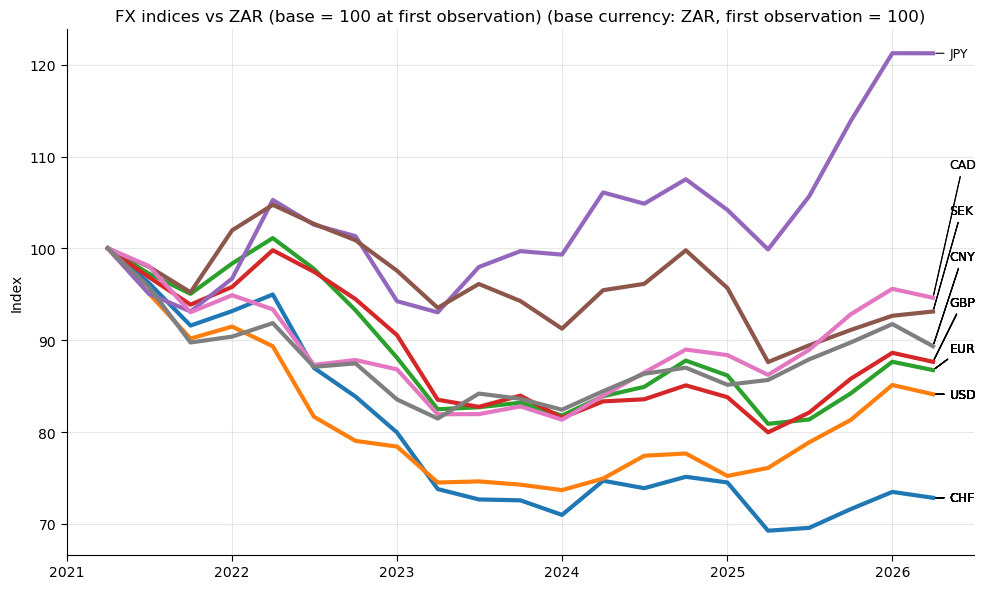

In [4]:
er.plot_indexed_fx(
    fx_ccy,
    min_label_gap=5.0,
    title="FX indices vs ZAR (base = 100 at first observation)",
)

### 1.2 Quarterly Log-Returns

Returns are computed as log-differences of the quarterly averages.
A **positive** return means the foreign currency appreciated against ZAR
(1 ZAR buys *more* of the foreign currency → ZAR strengthened).

In [5]:
fx_returns = er.get_fx_returns(fx_ccy)
print(f"Return observations: {len(fx_returns)} quarters")
print()
print("Summary statistics (quarterly log-returns):")
summary = fx_returns.describe().T
summary.columns = summary.columns.str.replace('%', 'pct', regex=False)
# show std as percentage for readability
display_stats = fx_returns.describe().T[['mean', 'std', 'min', 'max']]
display_stats.columns = ['Mean (log)', 'Std (log)', 'Min', 'Max']
display_stats['Std (%)'] = (fx_returns.std() * 100).values
display_stats.style.format({
    'Mean (log)': '{:.4f}',
    'Std (log)':  '{:.4f}',
    'Min':        '{:.4f}',
    'Max':        '{:.4f}',
    'Std (%)':    '{:.2f}',
})

Return observations: 20 quarters

Summary statistics (quarterly log-returns):


,Mean (log),Std (log),Min,Max,Std (%)
ZAR_CHF,-0.0158,0.0384,-0.0879,0.0511,3.84
ZAR_USD,-0.0086,0.0352,-0.0898,0.0457,3.52
ZAR_EUR,-0.0071,0.0345,-0.0657,0.0401,3.45
ZAR_GBP,-0.0066,0.0334,-0.0808,0.0438,3.34
ZAR_JPY,0.0096,0.0456,-0.0725,0.0847,4.56
ZAR_SEK,-0.0036,0.0372,-0.0880,0.0685,3.72
ZAR_CAD,-0.0028,0.0318,-0.0669,0.0426,3.18
ZAR_CNY,-0.0056,0.0296,-0.0651,0.0328,2.96


### 1.3 Correlation Matrix (std % on diagonal)

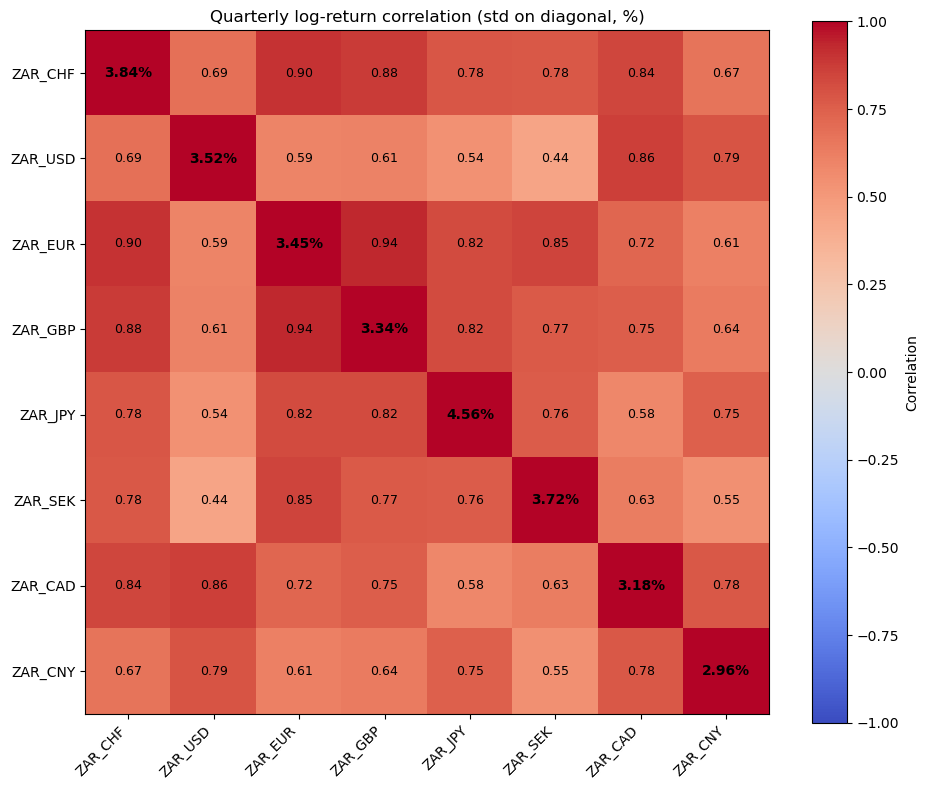

In [6]:
er.plot_corr_with_std(
    fx_returns,
    title="Quarterly log-return correlation (std on diagonal, %)"
)

### 1.4 Scatterplot Matrix

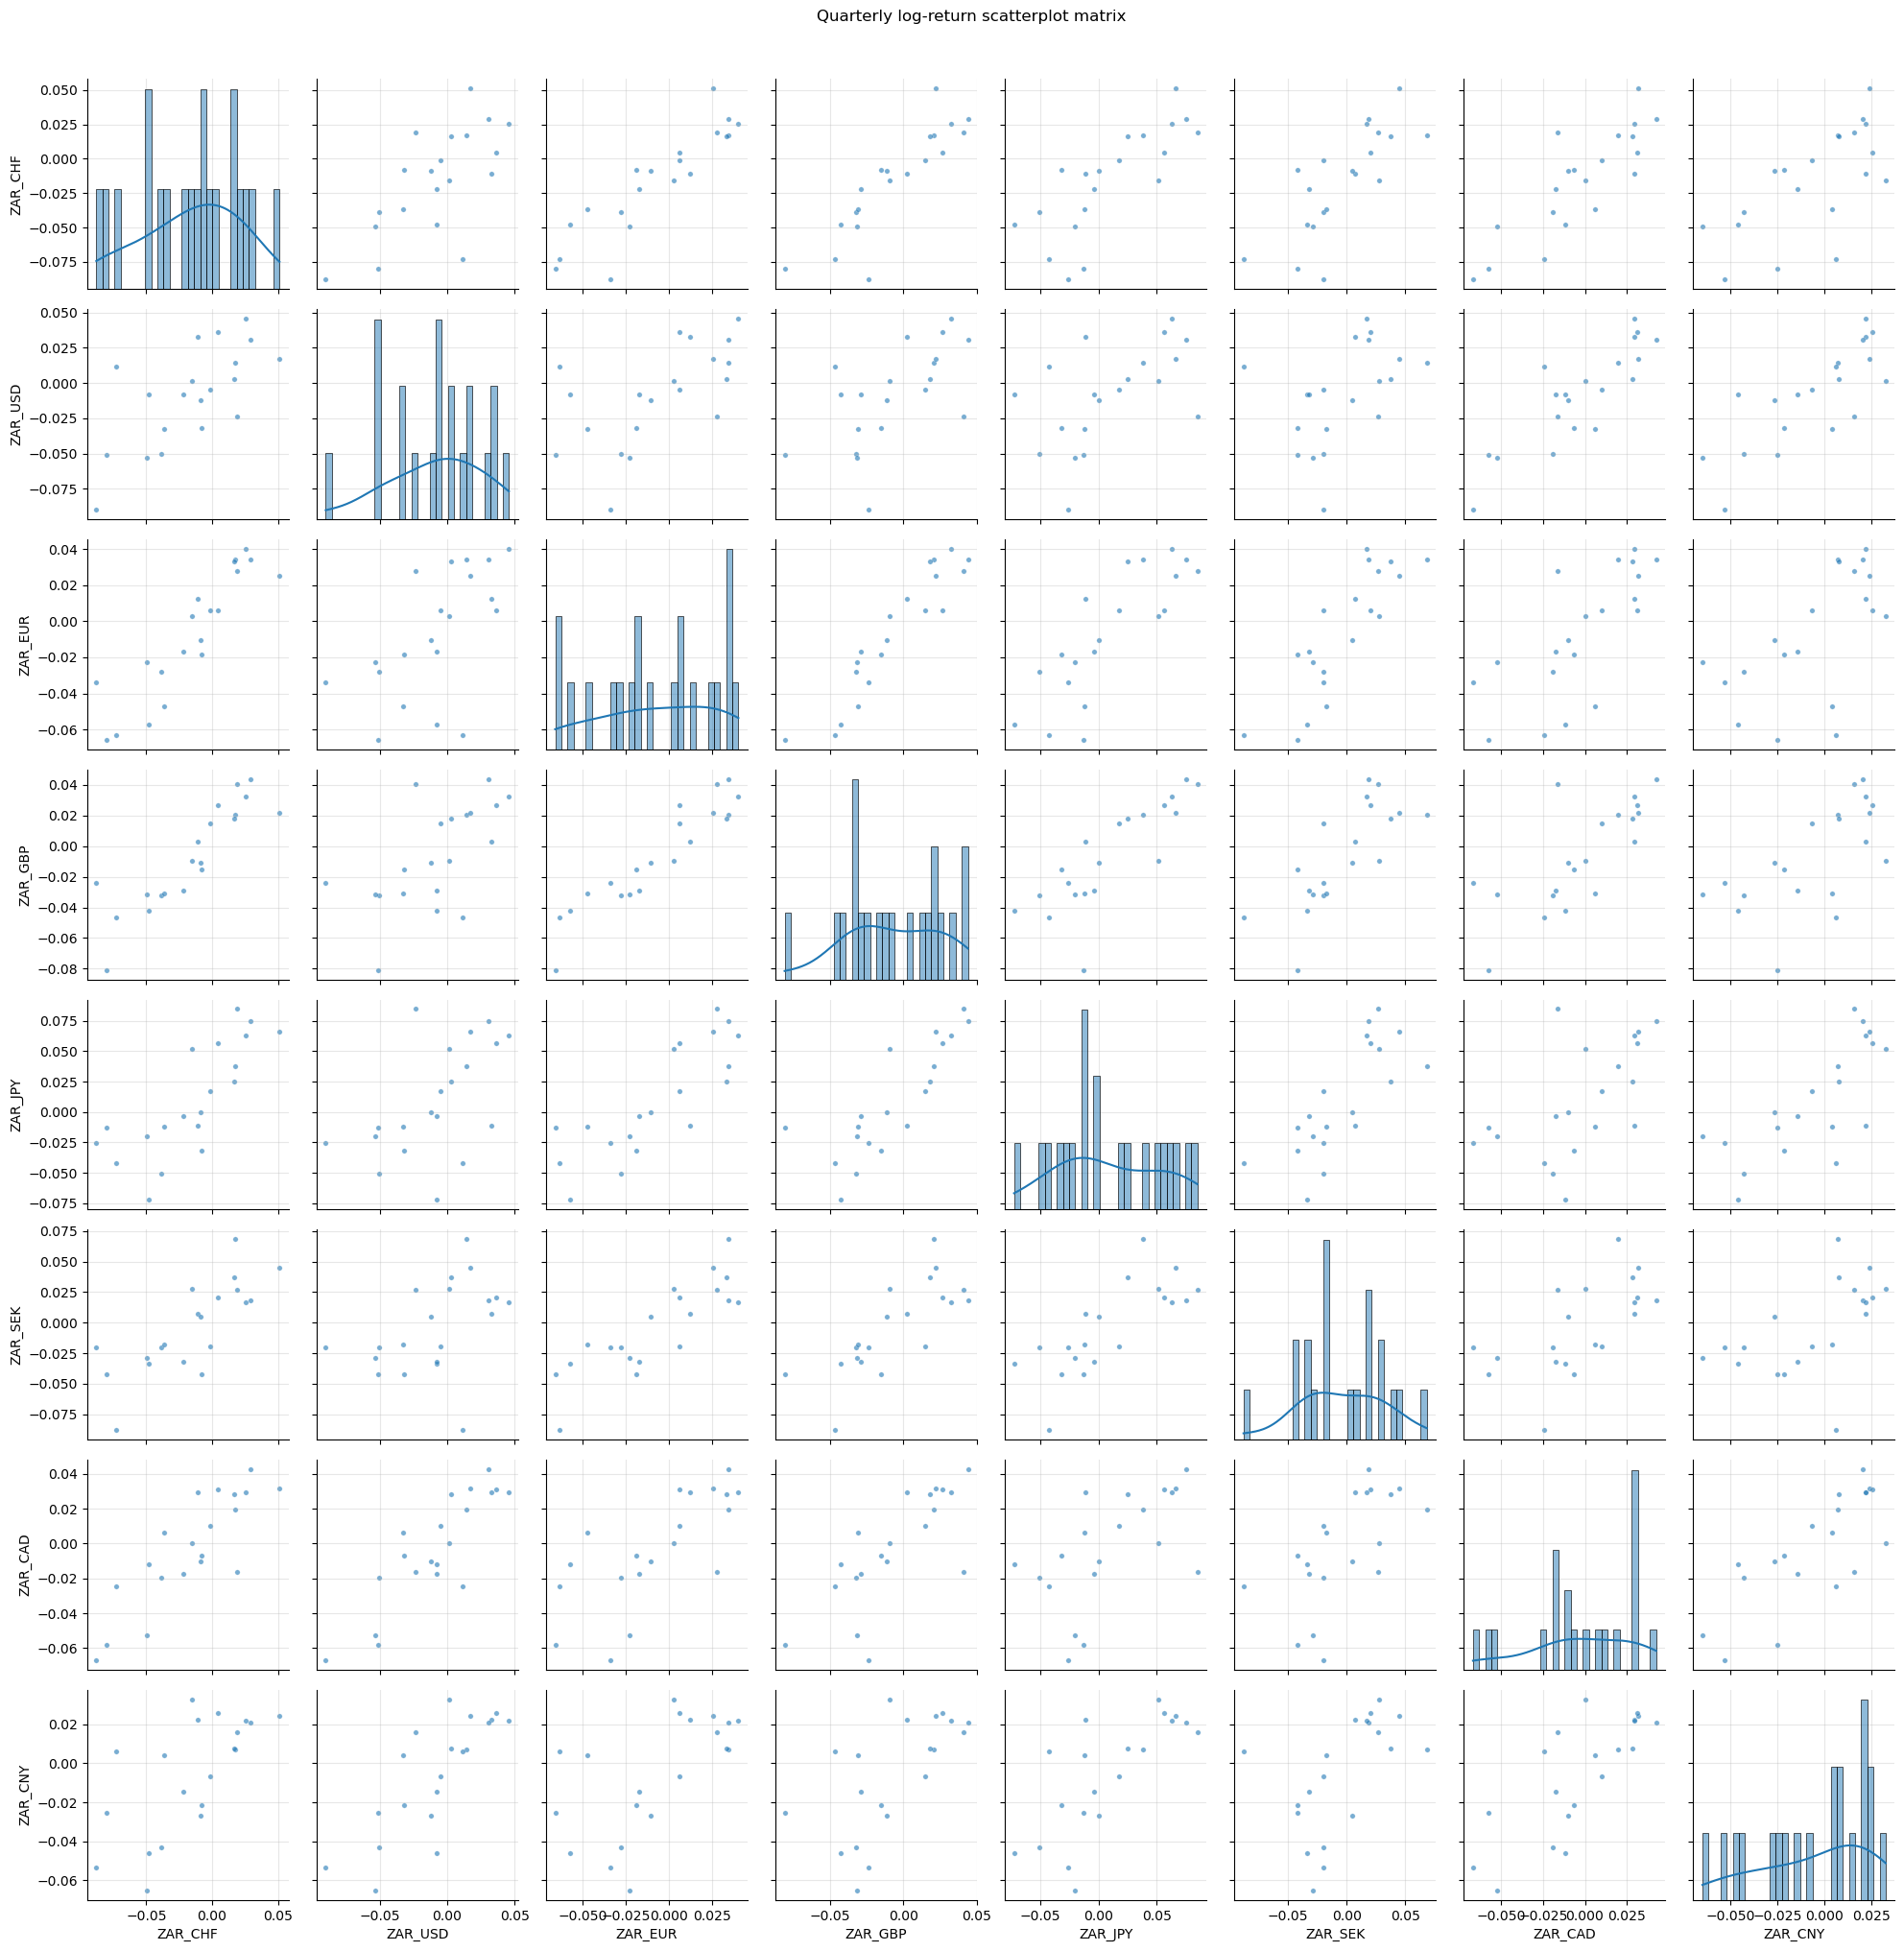

In [7]:
er.plot_return_scatter_matrix_with_marginals(
    fx_returns,
    title="Quarterly log-return scatterplot matrix"
)

### 1.5 Covariance Matrix

In [8]:
fx_cov = er.get_fx_covariance(fx_returns)

std = pd.Series(
    np.sqrt(np.diag(fx_cov.values)) * 100,
    index=fx_cov.index,
    name="Quarterly std (%)"
)
print("Quarterly FX standard deviations (% per quarter):")
display(std.to_frame().T)
print()
print("Covariance matrix:")
fx_cov

Quarterly FX standard deviations (% per quarter):


,ZAR_CHF,ZAR_USD,ZAR_EUR,ZAR_GBP,ZAR_JPY,ZAR_SEK,ZAR_CAD,ZAR_CNY
Quarterly std (%),3.842451,3.515658,3.45144,3.344069,4.56236,3.715764,3.176363,2.957535



Covariance matrix:


,ZAR_CHF,ZAR_USD,ZAR_EUR,ZAR_GBP,ZAR_JPY,ZAR_SEK,ZAR_CAD,ZAR_CNY
ZAR_CHF,0.001476,0.000928,0.001194,0.001134,0.001371,0.001110,0.001029,0.000759
ZAR_USD,0.000928,0.001236,0.000722,0.000715,0.000860,0.000575,0.000965,0.000824
ZAR_EUR,0.001194,0.000722,0.001191,0.001081,0.001298,0.001088,0.000794,0.000627
ZAR_GBP,0.001134,0.000715,0.001081,0.001118,0.001256,0.000953,0.000798,0.000630
ZAR_JPY,0.001371,0.000860,0.001298,0.001256,0.002082,0.001290,0.000839,0.001009
ZAR_SEK,0.001110,0.000575,0.001088,0.000953,0.001290,0.001381,0.000742,0.000600
ZAR_CAD,0.001029,0.000965,0.000794,0.000798,0.000839,0.000742,0.001009,0.000729
ZAR_CNY,0.000759,0.000824,0.000627,0.000630,0.001009,0.000600,0.000729,0.000875


---
## Section 2 — Mean-Variance Efficient Frontier (foreign currencies only)

The MV frontier sweeps risk-aversion λ from 0 (minimum risk) to 1 (minimum
cost) and finds the optimal portfolio weights at each point. The **risk** axis
is the portfolio's quarterly FX-return volatility; the **cost** axis is the
expected annual debt cost (`interest_rate + expected_appreciation`).

Edit the assumptions in the interactive grid, then press **Run frontier**.

In [9]:
# ── Rename covariance matrix: drop 'ZAR_' prefix ─────────────────────────────
cov_df = fx_cov.rename(
    index=lambda x: x.split('_')[1],
    columns=lambda x: x.split('_')[1],
)
names = cov_df.index
n = len(names)

# Approximate sovereign borrowing costs (annual), as of 2025
# Adjust these to reflect current market conditions or your own assumptions.
interest_rates = {
    'CHF': 0.005,   # Swiss franc  — very low rates
    'USD': 0.043,   # US dollar    — elevated Fed rates
    'EUR': 0.025,   # Euro         — ECB policy rate
    'GBP': 0.045,   # Pound        — Bank of England
    'JPY': 0.005,   # Yen          — near-zero Bank of Japan
    'SEK': 0.020,   # Swedish krona
    'CAD': 0.030,   # Canadian dollar
    'CNY': 0.025,   # Chinese yuan
}

assumptions = pd.DataFrame(
    {
        'interest_rate':         [interest_rates.get(c, 0.02) for c in names],
        'expected_appreciation': [0.0] * n,
        'min_share':             [0.0] * n,
        'max_share':             [1.0] * n,
        'current_share':         [1.0 / n] * n,   # equal-weight baseline
    },
    index=names,
)
assumptions

,interest_rate,expected_appreciation,min_share,max_share,current_share
CHF,0.005,0.0,0.0,1.0,0.125
USD,0.043,0.0,0.0,1.0,0.125
EUR,0.025,0.0,0.0,1.0,0.125
GBP,0.045,0.0,0.0,1.0,0.125
JPY,0.005,0.0,0.0,1.0,0.125
SEK,0.020,0.0,0.0,1.0,0.125
CAD,0.030,0.0,0.0,1.0,0.125
CNY,0.025,0.0,0.0,1.0,0.125


In [10]:
inputs = er.DebtFrontierInputs(
    cov_df=cov_df,
    assumptions=assumptions,
    name='xlsx_basis',
    chartfolder='graph/',
)
inputs.widget()

---
## Section 3 — Including Domestic (ZAR) Debt

Domestic ZAR debt carries **zero FX risk** (its covariance with all foreign
currencies is zero) but typically a higher nominal interest rate. Adding it
extends the frontier to lower-risk portfolios.

The default domestic rate below is 8 % — adjust in the widget.

In [11]:
# Extend covariance matrix with a ZAR row/column of zeros (no FX risk)
cov_df_dom = cov_df.reindex(
    index=list(cov_df.index) + ['ZAR'],
    columns=list(cov_df.columns) + ['ZAR'],
    fill_value=0.0,
)

# ZAR assumption row — current_share=0 keeps foreign Σ=1 in the widget indicator
zar_row = pd.DataFrame(
    {
        'interest_rate':         [0.08],   # 8 % domestic rate — placeholder
        'expected_appreciation': [0.0],
        'min_share':             [0.0],
        'max_share':             [1.0],
        'current_share':         [0.0],
    },
    index=['ZAR'],
)
assumptions_dom = pd.concat([assumptions, zar_row])

inputs_dom = er.DebtFrontierInputs(
    cov_df=cov_df_dom,
    assumptions=assumptions_dom,
    name='xlsx_with_domestic',
    chartfolder='graph/',
)
inputs_dom.widget()

---
## Section 4 — Scripted Scenario Loop (no widget)

For batch runs or report generation, use `inputs.plot()` directly.
The example below sweeps three domestic-rate assumptions and writes
each frontier to `graph/`.  

Running scenario: dom_5pct  (ZAR rate = 5%)


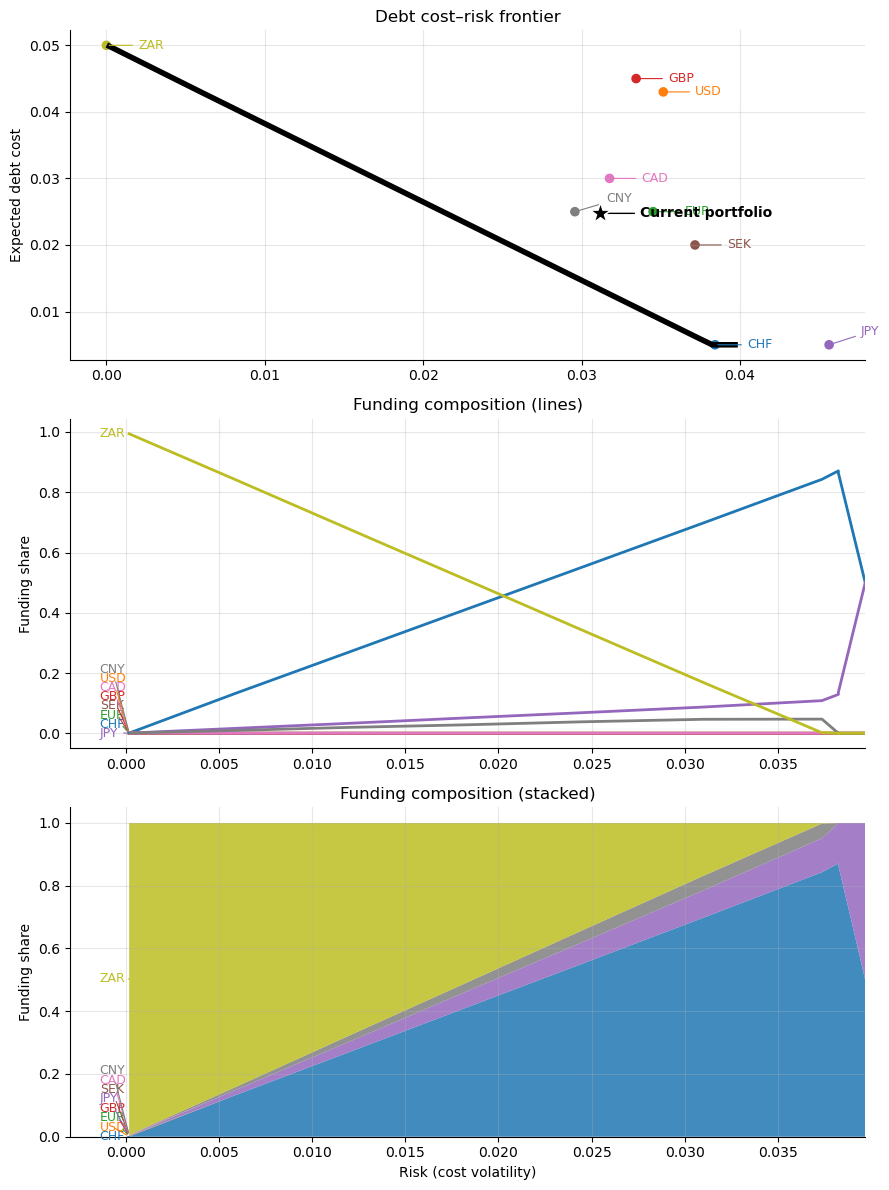

Running scenario: dom_8pct  (ZAR rate = 8%)


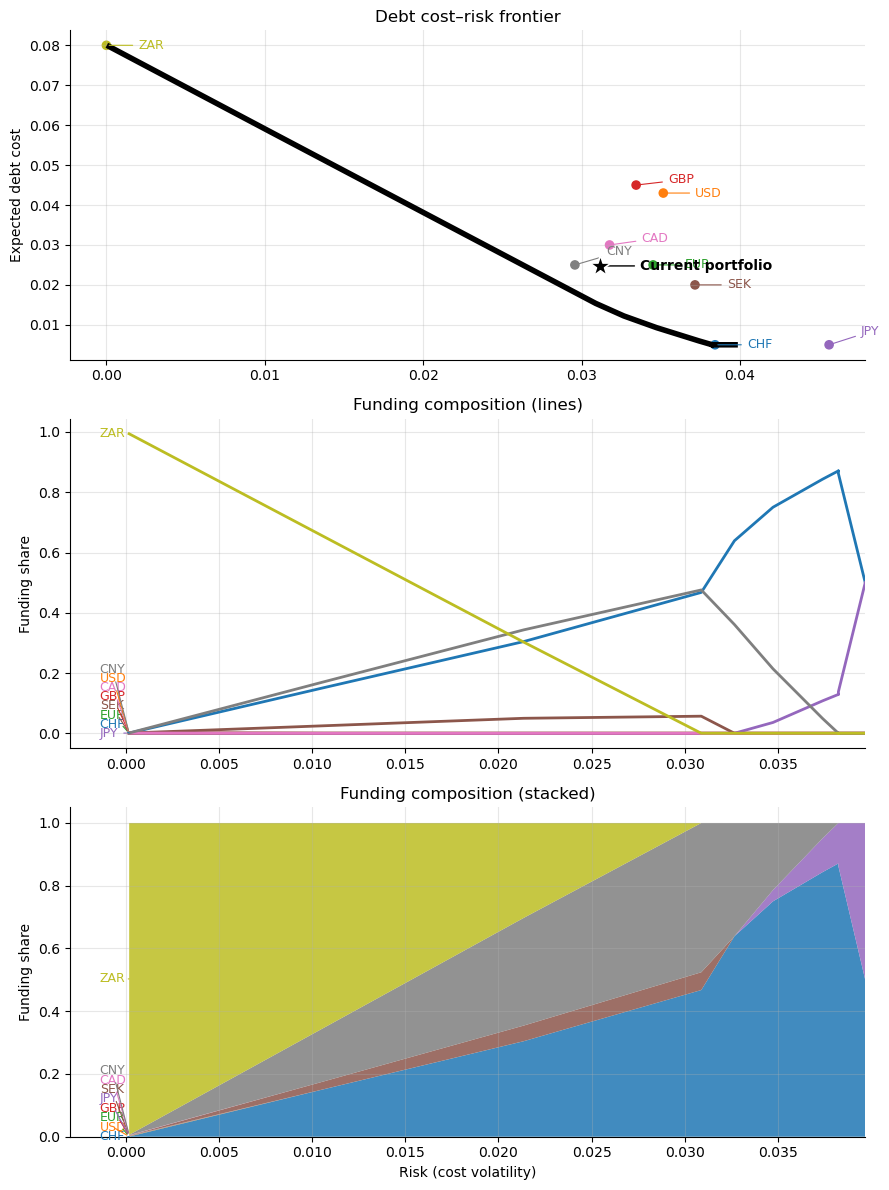

Running scenario: dom_11pct  (ZAR rate = 11%)


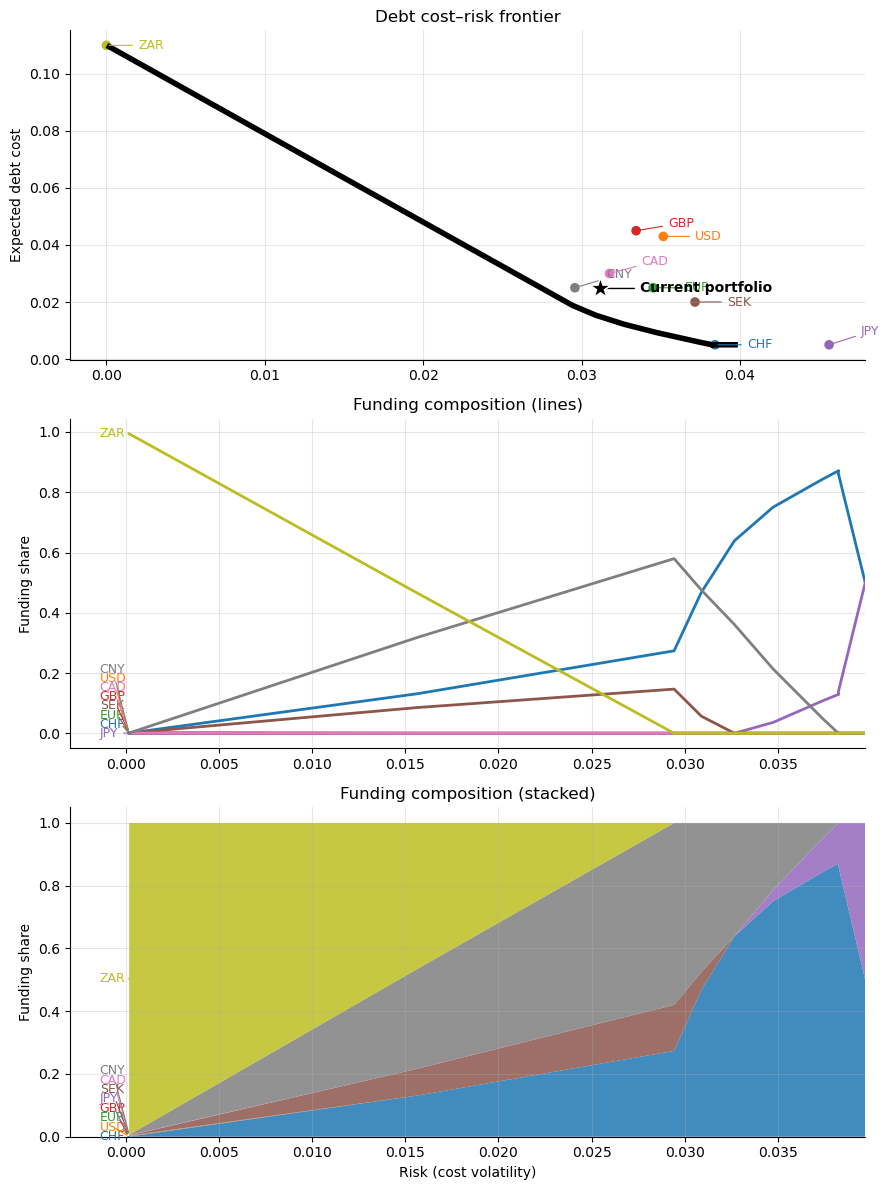

In [12]:
scenarios = {
    'dom_5pct':  0.05,
    'dom_8pct':  0.08,
    'dom_11pct': 0.11,
}

for scenario_name, dom_rate in scenarios.items():
    inp = er.DebtFrontierInputs(
        cov_df=cov_df_dom,
        assumptions=assumptions_dom.copy(),
        name=scenario_name,
        chartfolder='graph/',
    )
    inp.assumptions.at['ZAR', 'interest_rate'] = dom_rate
    print(f"Running scenario: {scenario_name}  (ZAR rate = {dom_rate:.0%})")
    inp.plot(export_formats=('svg',))